
# QuantRisk AI — Module 7: LIME Analysis

## Objective
Use **LIME (Local Interpretable Model-agnostic Explanations)** to explain individual 20-trading-day future-volatility forecasts produced by the LSTM model from Module 5.

### Explainability framework
- **SHAP (Module 6):** global and local attribution using SHAP values.
- **LIME (Module 7):** local surrogate-model explanations around selected predictions.
- Both explain the **continuous volatility forecast**, not causality.
- The risk class is derived afterward by comparing the forecast with the training-derived risk threshold.

### Leakage-safe design
This notebook:
1. Loads the feature-engineered dataset created in Module 3.
2. Loads the exact LSTM and preprocessing artifacts from Module 5.
3. Reconstructs the Module 5 future-volatility target exactly.
4. Reconstructs the final Module 5 60-day sequences exactly, including pre-split history.
5. Verifies prediction consistency with Module 5.
6. Uses feature-level perturbations across the complete 60-day history, with the exact Module 5 feature order.
7. Generates local LIME explanations for representative test cases.


In [2]:
# ============================================================
# 1. Imports & Configuration
# ============================================================

import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch import nn

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_PATH = "../backend/data/feature_engineered_dataset.csv"
MODEL_PATH = "../backend/models/lstm_volatility_model.pt"
PREPROCESSING_PATH = "../backend/models/lstm_preprocessing.pkl"
MODULE5_PRED_PATH = "../backend/models/lstm_test_predictions.csv"

OUTPUT_DIR = "../backend/models/lime"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOOKBACK = 60
HORIZON = 20

TRAIN_END = "2023-12-31"
VAL_END = "2024-12-31"

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.14.1+cpu
Device: cpu


In [3]:

# ============================================================
# 2. Load Module 3 Feature-Engineered Dataset
# ============================================================

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values(["Stock", "Date"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Stocks:", df["Stock"].nunique())


Dataset shape: (70764, 37)
Date range: 2020-01-02 to 2025-12-31
Stocks: 49


In [4]:

# ============================================================
# 3. Configuration from Module 5
# ============================================================

FEATURES = [
    "Daily_Return",
    "Rolling_Volatility_20D",
    "Rolling_Volatility_60D",
    "Price_MA20_Ratio",
    "Price_MA50_Ratio",
    "Momentum_20D",
    "RSI_14",
    "MACD",
    "MACD_Histogram",
    "ATR_14",
    "Beta_Causal",
    "Volatility_Ratio",
    "Volume_Ratio",
    "Volume_Change",
    "High_Low_Pct",
    "Gap_Pct",
]

assert all(c in df.columns for c in FEATURES)

# EXACT Module 5 target construction.
# For date t, use returns t+1 through t+20 for the same stock.
def future_volatility(series, horizon=20):
    values = series.to_numpy(dtype=float)
    out = np.full(len(values), np.nan)
    for i in range(len(values) - horizon):
        window = values[i + 1:i + 1 + horizon]
        if np.isfinite(window).all():
            out[i] = np.std(window, ddof=1)
    return pd.Series(out, index=series.index)

df["Future_Volatility_20D"] = (
    df.groupby("Stock", group_keys=False)["Daily_Return"]
      .apply(lambda s: future_volatility(s, HORIZON))
)

print("Number of features:", len(FEATURES))
print("Valid targets:", df["Future_Volatility_20D"].notna().sum())


Number of features: 16
Valid targets: 69784


In [5]:
# ============================================================
# 4. Chronological Split + EXACT Module 5 Trading-Date Purge
# ============================================================

TRAIN_END = pd.Timestamp("2023-12-31")
VAL_END = pd.Timestamp("2024-12-31")
TEST_END = pd.Timestamp("2025-12-31")

# IMPORTANT:
# Use the same global market-session index as Module 5.
# The purge is based on actual dates in the dataset, NOT on a
# per-stock row count. This keeps Module 7 perfectly aligned
# with Module 5.

trading_dates = np.sort(df["Date"].dropna().unique())

# Map every actual trading date to one global market-session index.
date_to_idx = pd.Series(
    np.arange(len(trading_dates)),
    index=trading_dates
)

df["Market_Day_Index"] = df["Date"].map(date_to_idx)

# Find the last actual dataset trading date on/before each boundary.
train_end_date = trading_dates[trading_dates <= TRAIN_END][-1]
val_end_date = trading_dates[trading_dates <= VAL_END][-1]

train_end_idx = int(date_to_idx.loc[train_end_date])
val_end_idx = int(date_to_idx.loc[val_end_date])

# A target at date t uses returns t+1 ... t+20.
# Therefore the final 20 market sessions at the train and validation
# boundaries are purged so labels cannot extend into the next period.

train_mask = (
    (df["Date"] <= TRAIN_END) &
    df["Future_Volatility_20D"].notna() &
    (df["Market_Day_Index"] <= train_end_idx - HORIZON)
)

val_mask = (
    (df["Date"] > TRAIN_END) &
    (df["Date"] <= VAL_END) &
    df["Future_Volatility_20D"].notna() &
    (df["Market_Day_Index"] <= val_end_idx - HORIZON)
)

test_mask = (
    (df["Date"] > VAL_END) &
    (df["Date"] <= TEST_END) &
    df["Future_Volatility_20D"].notna()
)

# Convert masks to integer indices for sequence construction.
train_idx = df.index[train_mask].to_numpy()
val_idx = df.index[val_mask].to_numpy()
test_idx = df.index[test_mask].to_numpy()

print("Train rows:", len(train_idx))
print("Validation rows:", len(val_idx))
print("Test rows:", len(test_idx))

print("Train last date:", df.loc[train_idx, "Date"].max().date())
print("Validation last date:", df.loc[val_idx, "Date"].max().date())
print("Test first date:", df.loc[test_idx, "Date"].min().date())
print("Test last date:", df.loc[test_idx, "Date"].max().date())


Train rows: 45725
Validation rows: 10976
Test rows: 11123
Train last date: 2023-11-30
Validation last date: 2024-12-02
Test first date: 2025-01-02
Test last date: 2025-12-02


In [6]:
# ============================================================
# 5. Load Train-Fitted Preprocessing
# ============================================================

# Module 5 fitted the imputer and scaler using TRAIN observations only.
# We reuse those exact fitted objects here; nothing is refitted.
#
# IMPORTANT: Module 5's FINAL LSTM notebook used the train-fitted
# preprocessing on the COMPLETE chronological dataframe before sequence
# construction. This allows validation/test sequences to use their real
# preceding 59 observations from the previous period.

import joblib

preprocessing = joblib.load(PREPROCESSING_PATH)
imputer = preprocessing["imputer"]
scaler = preprocessing["scaler"]

fitted_features = list(preprocessing.get("features", []))
if fitted_features != FEATURES:
    raise ValueError(
        "Feature-order mismatch with Module 5 preprocessing.\n"
        f"Module 7 FEATURES: {FEATURES}\n"
        f"Module 5 fitted features: {fitted_features}"
    )

# Fit is NOT performed here. Both objects were already fitted in Module 5.
# Transform the COMPLETE dataframe with the train-fitted objects.
X_all_raw = df[FEATURES].copy()
X_all_scaled = scaler.transform(imputer.transform(X_all_raw))

if not np.isfinite(X_all_scaled).all():
    raise ValueError("Non-finite values remain after Module 5 preprocessing.")

print("Preprocessing feature-order check: PASS")
print("Full scaled matrix:", X_all_scaled.shape)
print("Imputer/scaler reused from Module 5: PASS")


Preprocessing feature-order check: PASS
Full scaled matrix: (70764, 16)
Imputer/scaler reused from Module 5: PASS


In [19]:
# ============================================================
# 6. Build 60-Day Sequences — EXACT FINAL Module 5 Logic
# ============================================================

# CRITICAL:
# Module 5 uses PRE-SPLIT HISTORY.
#
# For every target date, the LSTM uses:
#   previous 59 observations + current observation
#
# This means validation/test sequences can use observations
# from the immediately preceding period as historical context.
#
# Expected sequence counts:
#   Train      = 42,834
#   Validation = 10,976
#   Test       = 11,123


def make_sequences_with_history(
    dataframe,
    target_mask,
    X_all_scaled,
    lookback=60
):
    
    target_indices = np.flatnonzero(
        target_mask.to_numpy()
    )

    X_list = []
    y_list = []
    meta = []

    # Stock-specific chronological positions.
    stock_positions = {
        stock: g.index.to_numpy()
        for stock, g in dataframe.groupby(
            "Stock",
            sort=False
        )
    }

    for idx in target_indices:

        stock = dataframe.at[idx, "Stock"]
        positions = stock_positions[stock]

        # Position of target within this stock's history.
        loc = np.searchsorted(
            positions,
            idx
        )

        # Need 59 previous observations + current observation.
        if loc < lookback - 1:
            continue

        # Exactly 60 observations.
        window_positions = positions[
            loc - lookback + 1 : loc + 1
        ]

        window = X_all_scaled[
            window_positions
        ]

        # Safety checks.
        if window.shape != (
            lookback,
            len(FEATURES)
        ):
            continue

        if not np.isfinite(window).all():
            continue

        X_list.append(window)

        y_list.append(
            float(
                dataframe.at[
                    idx,
                    "Future_Volatility_20D"
                ]
            )
        )

        meta.append(
            (
                dataframe.at[idx, "Date"],
                stock,
                idx
            )
        )

    X = np.asarray(
        X_list,
        dtype=np.float32
    )

    y = np.asarray(
        y_list,
        dtype=np.float32
    )

    meta = pd.DataFrame(
        meta,
        columns=[
            "Date",
            "Stock",
            "Global_Index"
        ]
    )

    return X, y, meta


# ============================================================
# Build Train / Validation / Test Sequences
# ============================================================

Xtr, ytr, mtr = make_sequences_with_history(
    df,
    train_mask,
    X_all_scaled,
    LOOKBACK
)

Xva, yva, mva = make_sequences_with_history(
    df,
    val_mask,
    X_all_scaled,
    LOOKBACK
)

Xte, yte, mte = make_sequences_with_history(
    df,
    test_mask,
    X_all_scaled,
    LOOKBACK
)


print(
    "Train sequences:",
    Xtr.shape,
    ytr.shape
)

print(
    "Validation sequences:",
    Xva.shape,
    yva.shape
)

print(
    "Test sequences:",
    Xte.shape,
    yte.shape
)


# ============================================================
# Load Module 5 Saved Predictions
# ============================================================

module5_pred = pd.read_csv(
    MODULE5_PRED_PATH
)

module5_pred.columns = (
    module5_pred.columns
    .astype(str)
    .str.strip()
)


# ============================================================
# Validate Required Columns
# ============================================================

required_base = {
    "Stock",
    "Date"
}

missing_base = (
    required_base -
    set(module5_pred.columns)
)

if missing_base:

    raise ValueError(
        "Module 5 prediction file is missing "
        f"required columns: {sorted(missing_base)}. "
        f"Available columns: "
        f"{module5_pred.columns.tolist()}"
    )


# ============================================================
# Clean Module 5 Metadata
# ============================================================

module5_pred["Stock"] = (
    module5_pred["Stock"]
    .astype(str)
    .str.strip()
)

module5_pred["Date"] = pd.to_datetime(
    module5_pred["Date"],
    errors="raise"
)


# ============================================================
# Identify Prediction Column
# ============================================================

canonical = {
    c.lower(): c
    for c in module5_pred.columns
}


if "predicted_volatility_20d" in canonical:

    MODULE5_PRED_COLUMN = canonical[
        "predicted_volatility_20d"
    ]

else:

    excluded = {
        "stock",
        "date",
        "actual_volatility_20d",
        "actual_high_risk",
        "predicted_high_risk"
    }

    prediction_candidates = [
        c
        for c in module5_pred.columns
        if c.lower() not in excluded
        and pd.api.types.is_numeric_dtype(
            module5_pred[c]
        )
        and any(
            token in c.lower()
            for token in (
                "pred",
                "forecast"
            )
        )
    ]

    if len(prediction_candidates) == 1:

        MODULE5_PRED_COLUMN = (
            prediction_candidates[0]
        )

    else:

        raise ValueError(
            "Could not identify the Module 5 "
            "volatility prediction column. "
            "Available columns: "
            + str(
                module5_pred.columns.tolist()
            )
        )


print(
    "Module 5 prediction column used:",
    MODULE5_PRED_COLUMN
)


# ============================================================
# Stock-Date Population Check
# ============================================================

# Module 7 keys
m7_keys = pd.DataFrame({
    "Stock": (
        mte["Stock"]
        .astype(str)
        .str.strip()
    ),
    "Date": pd.to_datetime(
        mte["Date"]
    )
})


# Module 5 keys
m5_keys = pd.DataFrame({
    "Stock": (
        module5_pred["Stock"]
        .astype(str)
        .str.strip()
    ),
    "Date": pd.to_datetime(
        module5_pred["Date"]
    )
})


# ============================================================
# Check Duplicate Stock-Date Keys
# ============================================================

if m7_keys.duplicated(
    subset=["Stock", "Date"]
).any():

    raise ValueError(
        "Module 7 contains duplicate "
        "Stock-Date observations."
    )


if m5_keys.duplicated(
    subset=["Stock", "Date"]
).any():

    raise ValueError(
        "Module 5 prediction file contains "
        "duplicate Stock-Date observations."
    )


# ============================================================
# Compare Populations
# ============================================================

m7_set = set(
    zip(
        m7_keys["Stock"],
        m7_keys["Date"]
    )
)

m5_set = set(
    zip(
        m5_keys["Stock"],
        m5_keys["Date"]
    )
)


m7_only = sorted(
    m7_set - m5_set
)

m5_only = sorted(
    m5_set - m7_set
)


print(
    "Module 7 test sequences:",
    len(m7_set)
)

print(
    "Module 5 saved predictions:",
    len(m5_set)
)

print(
    "Common Stock-Date:",
    len(
        m7_set & m5_set
    )
)

print(
    "Module 7-only:",
    len(m7_only)
)

print(
    "Module 5-only:",
    len(m5_only)
)


# ============================================================
# Final Population Validation
# ============================================================

if m7_only or m5_only:

    raise ValueError(
        "Module 7 and Module 5 test "
        "populations are NOT identical. "
        f"Module 7-only={len(m7_only)}, "
        f"Module 5-only={len(m5_only)}."
    )


print(
    "Test population check: PASS"
)


# ============================================================
# IMPORTANT
# ============================================================
#
# DO NOT compare m7_keys.equals(m5_keys).
#
# The two files can contain exactly the same Stock-Date
# observations while being stored in different physical
# row orders.
#
# Prediction alignment is performed later in Section 8,
# AFTER test_pred has been generated.
#
# Therefore Section 6 intentionally ends here.

Train sequences: (42834, 60, 16) (42834,)
Validation sequences: (10976, 60, 16) (10976,)
Test sequences: (11123, 60, 16) (11123,)
Module 5 prediction column used: Predicted_Volatility
Module 7 test sequences: 11123
Module 5 saved predictions: 11123
Common Stock-Date: 11123
Module 7-only: 0
Module 5-only: 0
Test population check: PASS


In [20]:
# ============================================================
# 7. Rebuild Exact Module 5 LSTM and Load Saved Checkpoint
# ============================================================

class VolatilityLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        last_hidden = output[:, -1, :]
        return self.fc(self.dropout(last_hidden)).squeeze(-1)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

# Module 5 saves a checkpoint dictionary containing model_state_dict.
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model_state = checkpoint["model_state_dict"]

    # Verify architecture metadata when available.
    if "input_size" in checkpoint:
        assert int(checkpoint["input_size"]) == len(FEATURES)
    if "lookback" in checkpoint:
        assert int(checkpoint["lookback"]) == LOOKBACK
    if "hidden_size" in checkpoint:
        assert int(checkpoint["hidden_size"]) == 64
    if "num_layers" in checkpoint:
        assert int(checkpoint["num_layers"]) == 2
    if "horizon" in checkpoint:
        assert int(checkpoint["horizon"]) == HORIZON
else:
    # Compatibility fallback for an older artifact containing only a state dict.
    model_state = checkpoint

model = VolatilityLSTM(
    input_size=len(FEATURES),
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(DEVICE)

model.load_state_dict(model_state)
model.eval()

print("Exact Module 5 LSTM checkpoint loaded: PASS")
print(model)


Exact Module 5 LSTM checkpoint loaded: PASS
VolatilityLSTM(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [21]:
# ============================================================
# 8. Prediction Consistency Check — Module 7 vs Module 5
# ============================================================

@torch.no_grad()
def predict_sequences(X, batch_size=512):
    predictions = []
    for start in range(0, len(X), batch_size):
        batch = torch.tensor(
            X[start:start + batch_size], dtype=torch.float32, device=DEVICE
        )
        predictions.append(model(batch).cpu().numpy().ravel())
    return np.concatenate(predictions)

# Predict using the exact Module 5 LSTM and the exact Module 5 test sequences.
test_pred = np.clip(predict_sequences(Xte), 0, None)

# IMPORTANT: the saved CSV may be in a different row order even when it contains
# exactly the same Stock-Date population. Therefore we align by the unique
# Stock-Date key instead of requiring identical row order.
m7_meta = mte[["Stock", "Date"]].copy().reset_index(drop=True)
m7_meta["Date"] = pd.to_datetime(m7_meta["Date"])
m7_meta["Sequence_Position"] = np.arange(len(m7_meta))
m7_meta["Module7_Predicted"] = test_pred

m5_meta = module5_pred[["Stock", "Date"]].copy().reset_index(drop=True)
m5_meta["Date"] = pd.to_datetime(m5_meta["Date"])
m5_meta["Stock"] = m5_meta["Stock"].astype(str).str.strip()
m5_meta["Module5_Predicted"] = module5_pred[MODULE5_PRED_COLUMN].to_numpy(dtype=np.float64)

# Check uniqueness before joining.
if m7_meta.duplicated(["Stock", "Date"]).any():
    raise ValueError("Module 7 contains duplicate Stock-Date keys.")
if m5_meta.duplicated(["Stock", "Date"]).any():
    raise ValueError("Module 5 prediction file contains duplicate Stock-Date keys.")

comparison = m7_meta.merge(
    m5_meta[["Stock", "Date", "Module5_Predicted"]],
    on=["Stock", "Date"],
    how="outer",
    indicator=True,
    validate="one_to_one"
)

m7_only = comparison.loc[comparison["_merge"] == "left_only", ["Stock", "Date"]]
m5_only = comparison.loc[comparison["_merge"] == "right_only", ["Stock", "Date"]]
common = comparison.loc[comparison["_merge"] == "both"].copy()

print("Module 7 test sequences:", len(m7_meta))
print("Module 5 saved predictions:", len(m5_meta))
print("Common Stock-Date:", len(common))
print("Module 7-only:", len(m7_only))
print("Module 5-only:", len(m5_only))

if len(m7_only) != 0 or len(m5_only) != 0:
    raise ValueError(
        "Module 7 and Module 5 test populations are NOT identical. "
        f"Module 7-only={len(m7_only)}, Module 5-only={len(m5_only)}."
    )

# Compare predictions after key-based alignment.
common["Absolute_Difference"] = np.abs(
    common["Module7_Predicted"] - common["Module5_Predicted"]
)

max_diff = float(common["Absolute_Difference"].max())
mean_diff = float(common["Absolute_Difference"].mean())

# Reorder Module 5 predictions into Module 7 sequence order for all later
# LIME/reporting steps. The numerical values are unchanged; only row alignment
# is standardized.
module5_aligned = (
    m7_meta[["Stock", "Date", "Sequence_Position"]]
    .merge(
        m5_meta[["Stock", "Date", "Module5_Predicted"]],
        on=["Stock", "Date"],
        how="left",
        validate="one_to_one"
    )
    .sort_values("Sequence_Position")
    .reset_index(drop=True)
)

if len(module5_aligned) != len(test_pred):
    raise ValueError(
        f"Aligned prediction length mismatch: Module 7={len(test_pred)}, "
        f"Module 5={len(module5_aligned)}."
    )

print("Maximum prediction difference:", max_diff)
print("Mean prediction difference:", mean_diff)

if max_diff >= 1e-6:
    raise ValueError(
        f"Model consistency check FAILED: maximum difference={max_diff:.12g}"
    )

print("Prediction order difference: handled by Stock-Date alignment")
print("Model consistency check: PASS")


Module 7 test sequences: 11123
Module 5 saved predictions: 11123
Common Stock-Date: 11123
Module 7-only: 0
Module 5-only: 0
Maximum prediction difference: 4.545536041317133e-09
Mean prediction difference: 5.330925976065549e-10
Prediction order difference: handled by Stock-Date alignment
Model consistency check: PASS


In [22]:
# ============================================================
# 9. Regression Performance Reference
# ============================================================

mae = mean_absolute_error(yte, test_pred)
rmse = np.sqrt(mean_squared_error(yte, test_pred))
r2 = r2_score(yte, test_pred)
corr = np.corrcoef(yte, test_pred)[0, 1]

print(f"Test MAE : {mae:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test R²  : {r2:.6f}")
print(f"Test Corr: {corr:.6f}")


Test MAE : 0.003592
Test RMSE: 0.004837
Test R²  : 0.307081
Test Corr: 0.584989


In [23]:
# ============================================================
# 10. Training-Derived Risk Threshold
# ============================================================

# Module 5 saved this threshold using the training target distribution.
# Reuse the saved value exactly; do not recompute it from validation/test.
if "risk_threshold" not in preprocessing:
    raise KeyError("risk_threshold not found in Module 5 preprocessing artifact.")

RISK_THRESHOLD = float(preprocessing["risk_threshold"])

print(
    f"Risk threshold: {RISK_THRESHOLD:.6f} "
    f"({RISK_THRESHOLD * 100:.2f}%)"
)


Risk threshold: 0.021286 (2.13%)


In [24]:
# ============================================================
# 11. LIME Representation
# ============================================================

# LIME is a local surrogate method. The LSTM input has 60 time steps x
# 16 features = 960 raw dimensions, which is difficult to interpret.
#
# Therefore each interpretable LIME variable represents ONE financial
# feature across the entire 60-day history.
#
# We use the most recent standardized value as the feature-level
# interpretable value. During perturbation, the corresponding delta is
# propagated across that feature's full 60-day trajectory.

def sequence_to_lime_vector(sequence):
    return sequence[-1, :].astype(np.float32, copy=True)

LIME_TRAIN_SIZE = min(len(Xtr), 5000)

lime_training_data = np.vstack([
    sequence_to_lime_vector(Xtr[i])
    for i in range(LIME_TRAIN_SIZE)
]).astype(np.float32)

assert lime_training_data.shape == (LIME_TRAIN_SIZE, len(FEATURES))

print("LIME interpretable variables:", len(FEATURES))
print("LIME training representation:", lime_training_data.shape)


LIME interpretable variables: 16
LIME training representation: (5000, 16)


In [25]:

# ============================================================
# 12. LIME Prediction Wrapper
# ============================================================

# LIME supplies perturbed 16-dimensional vectors.
# Each vector is interpreted as a perturbation of the most recent
# standardized feature values. The perturbation is propagated through
# the full 60-day sequence while preserving the original temporal
# pattern relative to the latest value.

def make_lime_predictor(original_sequence):
    base_last = original_sequence[-1].copy()

    def predictor(lime_matrix):
        lime_matrix = np.asarray(lime_matrix, dtype=np.float32)

        sequences = np.repeat(
            original_sequence[None, :, :],
            repeats=len(lime_matrix),
            axis=0
        )

        # Apply feature-level additive perturbations to the entire
        # 60-day feature trajectory.
        delta = lime_matrix - base_last

        for j in range(len(FEATURES)):
            sequences[:, :, j] += delta[:, j][:, None]

        return predict_sequences(sequences)

    return predictor

lime_feature_names = FEATURES.copy()

explainer = LimeTabularExplainer(
    training_data=lime_training_data,
    feature_names=lime_feature_names,
    mode="regression",
    discretize_continuous=False,
    random_state=SEED
)

print("LIME explainer created.")


LIME explainer created.


In [26]:
# ============================================================
# 13. Select Representative Test Cases
# ============================================================

rep = mte.copy().reset_index(drop=True)
rep["Actual"] = yte
rep["Predicted"] = test_pred
rep["Absolute_Error"] = np.abs(rep["Actual"] - rep["Predicted"])
rep["Risk_Class"] = np.where(
    rep["Predicted"] >= RISK_THRESHOLD,
    "High Risk",
    "Low Risk"
)
rep["Sequence_Position"] = np.arange(len(rep))

cases = {
    "Highest predicted volatility": rep["Predicted"].idxmax(),
    "Lowest predicted volatility": rep["Predicted"].idxmin(),
    "Largest prediction error": rep["Absolute_Error"].idxmax(),
    "Closest to risk threshold": (
        np.abs(rep["Predicted"] - RISK_THRESHOLD)
    ).idxmin()
}

case_rows = []
for label, idx in cases.items():
    row = rep.loc[idx].copy()
    row["Case"] = label
    case_rows.append(row)

representative_cases = pd.DataFrame(case_rows).reset_index(drop=True)

print(
    representative_cases[
        ["Case", "Stock", "Date", "Actual", "Predicted", "Absolute_Error", "Risk_Class"]
    ].to_string(index=False)
)


                        Case      Stock       Date   Actual  Predicted  Absolute_Error Risk_Class
Highest predicted volatility    ETERNAL 2025-01-22 0.034338   0.034437        0.000099  High Risk
 Lowest predicted volatility     MARUTI 2025-11-12 0.009648   0.004593        0.005055   Low Risk
    Largest prediction error INDUSINDBK 2025-03-06 0.067131   0.016624        0.050507   Low Risk
   Closest to risk threshold        BEL 2025-02-10 0.025368   0.021291        0.004077  High Risk


In [27]:
# ============================================================
# 14. Generate LIME Explanations
# ============================================================

lime_results = []
lime_explanations = {}

# representative_cases stores the original sequence position in
# Representative_Sequence_Position, so no fragile DataFrame-index lookup
# is required.
for _, case in representative_cases.iterrows():
    seq_position = int(case["Sequence_Position"])
    sequence = Xte[seq_position]

    vector = sequence_to_lime_vector(sequence)
    predictor = make_lime_predictor(sequence)

    explanation = explainer.explain_instance(
        data_row=vector,
        predict_fn=predictor,
        num_features=len(FEATURES),
        num_samples=1000
    )

    lime_explanations[case["Case"]] = explanation

    for feature, contribution in explanation.as_list():
        lime_results.append({
            "Case": case["Case"],
            "Stock": case["Stock"],
            "Date": case["Date"],
            "Actual": case["Actual"],
            "Predicted": case["Predicted"],
            "Risk_Class": case["Risk_Class"],
            "Feature": feature,
            "LIME_Contribution": contribution
        })

lime_df = pd.DataFrame(lime_results)

print("LIME explanations generated:", len(lime_explanations))
print("Rows in explanation table:", len(lime_df))


LIME explanations generated: 4
Rows in explanation table: 64


In [28]:

# ============================================================
# 15. Display Local Explanations
# ============================================================

for case_name, explanation in lime_explanations.items():
    print("\n" + "=" * 70)
    print(case_name)
    print("=" * 70)

    for feature, contribution in explanation.as_list():
        direction = "increases" if contribution > 0 else "decreases"
        print(f"{feature:30s} {contribution:+.6f}  -> {direction} local prediction")



Highest predicted volatility
High_Low_Pct                   +0.006426  -> increases local prediction
Rolling_Volatility_20D         +0.003167  -> increases local prediction
Rolling_Volatility_60D         +0.001956  -> increases local prediction
Volume_Ratio                   -0.001188  -> decreases local prediction
Volatility_Ratio               -0.001186  -> decreases local prediction
Price_MA50_Ratio               +0.001147  -> increases local prediction
Volume_Change                  -0.001047  -> decreases local prediction
Gap_Pct                        -0.001027  -> decreases local prediction
Daily_Return                   +0.001026  -> increases local prediction
ATR_14                         -0.000909  -> decreases local prediction
Price_MA20_Ratio               -0.000729  -> decreases local prediction
MACD_Histogram                 -0.000688  -> decreases local prediction
MACD                           -0.000591  -> decreases local prediction
Beta_Causal                    +0.

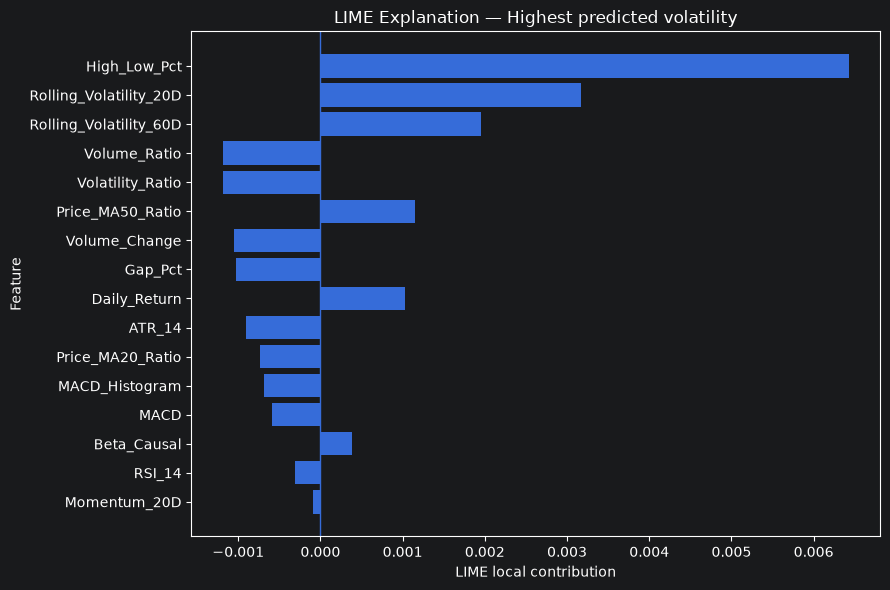

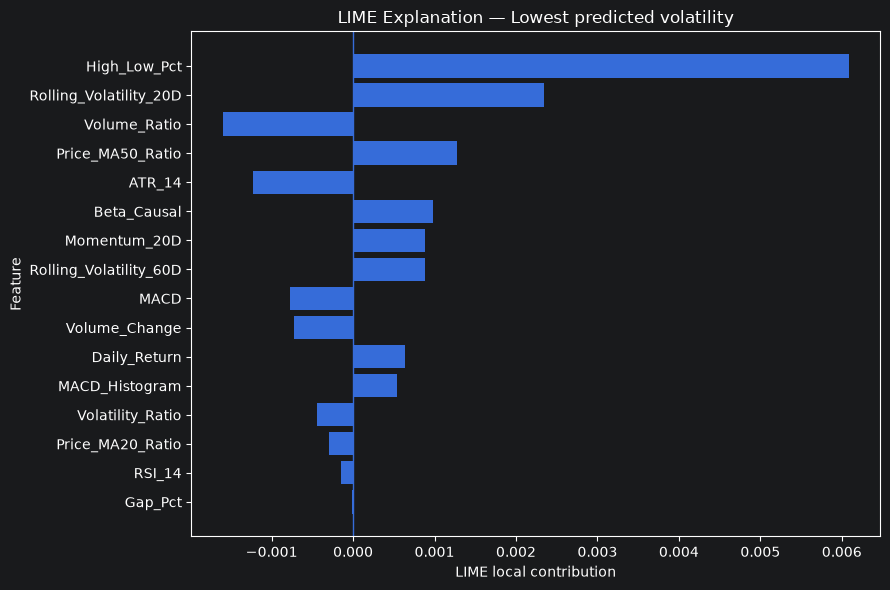

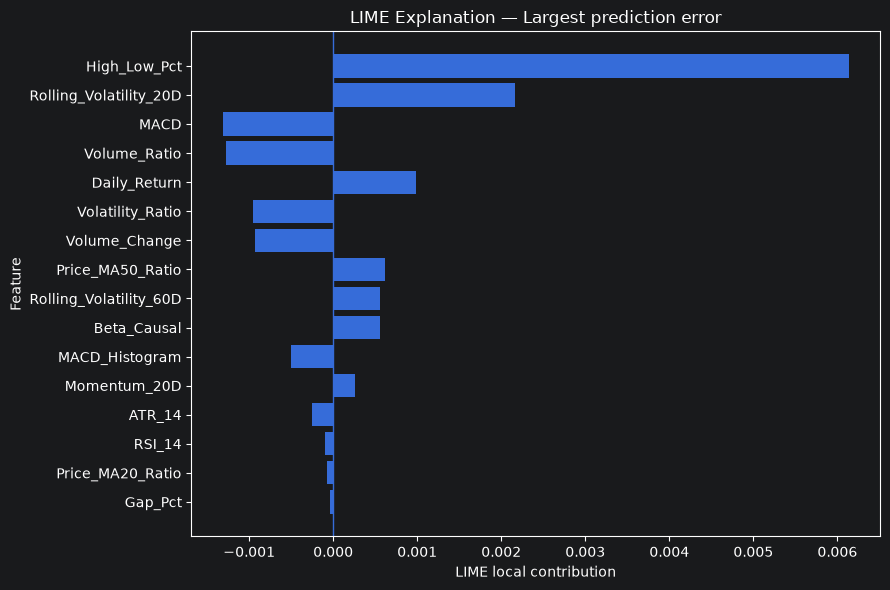

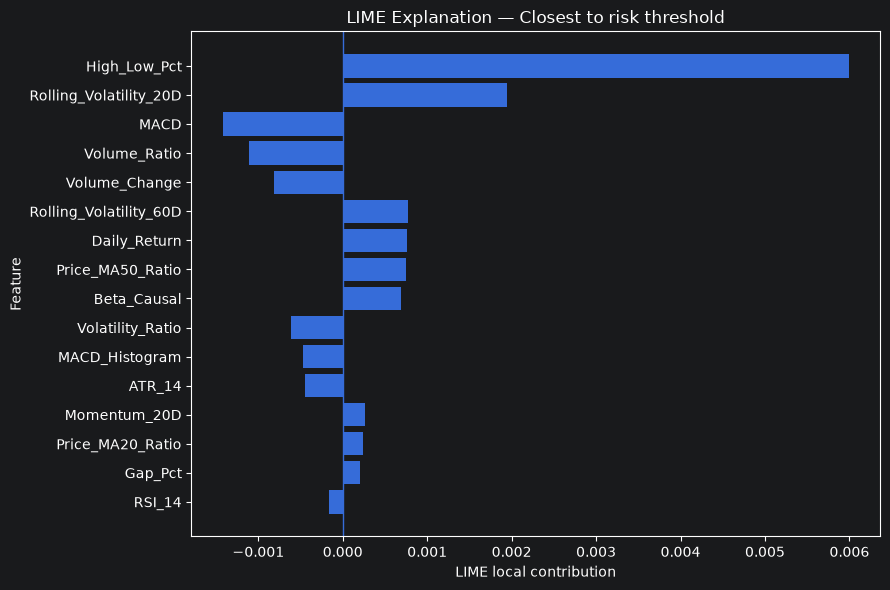

In [29]:

# ============================================================
# 16. Visualize Representative LIME Explanations
# ============================================================

for case_name, explanation in lime_explanations.items():

    labels = []
    values = []

    for feature, contribution in explanation.as_list():
        labels.append(feature)
        values.append(contribution)

    order = np.argsort(np.abs(values))
    labels = np.array(labels)[order]
    values = np.array(values)[order]

    plt.figure(figsize=(9, 6))
    plt.barh(labels, values)
    plt.axvline(0, linewidth=1)
    plt.xlabel("LIME local contribution")
    plt.ylabel("Feature")
    plt.title(f"LIME Explanation — {case_name}")
    plt.tight_layout()
    plt.show()


In [30]:

# ============================================================
# 17. Aggregate LIME Importance Across Representative Cases
# ============================================================

lime_global = (
    lime_df.assign(Absolute_Contribution=lambda x: x["LIME_Contribution"].abs())
    .groupby("Feature")["Absolute_Contribution"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Absolute_Contribution": "Mean_Absolute_LIME"})
)

print(lime_global.to_string(index=False))


               Feature  Mean_Absolute_LIME
          High_Low_Pct            0.006159
Rolling_Volatility_20D            0.002405
          Volume_Ratio            0.001294
Rolling_Volatility_60D            0.001043
                  MACD            0.001026
      Price_MA50_Ratio            0.000947
         Volume_Change            0.000877
          Daily_Return            0.000853
      Volatility_Ratio            0.000799
                ATR_14            0.000710
           Beta_Causal            0.000651
        MACD_Histogram            0.000550
          Momentum_20D            0.000378
      Price_MA20_Ratio            0.000334
               Gap_Pct            0.000321
                RSI_14            0.000180


In [31]:

# ============================================================
# 18. SHAP vs LIME Comparison
# ============================================================

shap_path = "models/shap/lstm_shap_global_importance.csv"

if os.path.exists(shap_path):
    shap_global = pd.read_csv(shap_path)

    shap_col = [c for c in shap_global.columns if "shap" in c.lower()]
    if shap_col:
        shap_col = shap_col[0]

        comparison = lime_global.merge(
            shap_global,
            on="Feature",
            how="outer"
        )

        print("SHAP vs LIME feature comparison:")
        print(comparison.to_string(index=False))
    else:
        comparison = None
        print("SHAP importance column not identified.")
else:
    comparison = None
    print("Module 6 SHAP global importance file not found.")


SHAP vs LIME feature comparison:
               Feature  Mean_Absolute_LIME  Mean_Abs_SHAP
                ATR_14            0.000710       0.000008
           Beta_Causal            0.000651       0.000007
          Daily_Return            0.000853       0.000007
               Gap_Pct            0.000321       0.000006
          High_Low_Pct            0.006159       0.000051
                  MACD            0.001026       0.000008
        MACD_Histogram            0.000550       0.000004
          Momentum_20D            0.000378       0.000008
      Price_MA20_Ratio            0.000334       0.000002
      Price_MA50_Ratio            0.000947       0.000010
                RSI_14            0.000180       0.000005
Rolling_Volatility_20D            0.002405       0.000024
Rolling_Volatility_60D            0.001043       0.000009
      Volatility_Ratio            0.000799       0.000011
         Volume_Change            0.000877       0.000011
          Volume_Ratio            0.001

In [32]:

# ============================================================
# 19. Representative Case Summary
# ============================================================

representative_summary = representative_cases[
    ["Case", "Stock", "Date", "Actual", "Predicted",
     "Absolute_Error", "Risk_Class"]
].copy()

representative_summary["Threshold"] = RISK_THRESHOLD

print(representative_summary.to_string(index=False))


                        Case      Stock       Date   Actual  Predicted  Absolute_Error Risk_Class  Threshold
Highest predicted volatility    ETERNAL 2025-01-22 0.034338   0.034437        0.000099  High Risk   0.021286
 Lowest predicted volatility     MARUTI 2025-11-12 0.009648   0.004593        0.005055   Low Risk   0.021286
    Largest prediction error INDUSINDBK 2025-03-06 0.067131   0.016624        0.050507   Low Risk   0.021286
   Closest to risk threshold        BEL 2025-02-10 0.025368   0.021291        0.004077  High Risk   0.021286


In [34]:
# ============================================================
# 20. Export LIME Artifacts
# ============================================================

lime_global.to_csv(
    f"{OUTPUT_DIR}/lstm_lime_global_importance.csv",
    index=False
)

lime_df.to_csv(
    f"{OUTPUT_DIR}/lstm_lime_local_explanations.csv",
    index=False
)

representative_summary.to_csv(
    f"{OUTPUT_DIR}/lstm_lime_representative_cases.csv",
    index=False
)

if comparison is not None:
    comparison.to_csv(
        f"{OUTPUT_DIR}/lstm_shap_vs_lime_comparison.csv",
        index=False
    )

print("LIME artifacts saved to:", OUTPUT_DIR)

LIME artifacts saved to: ../backend/models/lime



# 21. Methodology Checklist

### Data
- [x] Module 3 feature-engineered dataset reused
- [x] No raw-data duplication
- [x] Same 16 LSTM features

### Target
- [x] Future 20-trading-day realized volatility
- [x] Risk threshold derived from training data

### Leakage control
- [x] Chronological split
- [x] Trading-session purge
- [x] Pre-split 59-day history used for validation/test sequences, matching final Module 5
- [x] Train-fitted imputer/scaler reused
- [x] No test information used to fit preprocessing

### Model
- [x] Exact Module 5 LSTM architecture
- [x] Saved Module 5 model reused
- [x] Prediction consistency checked

### LIME
- [x] Local surrogate explanations
- [x] Continuous volatility forecast explained
- [x] Representative cases selected
- [x] Positive/negative local contributions reported
- [x] Global summary across representative cases exported

### Interpretation
LIME explanations describe **local model behavior**, not causal relationships.
A positive contribution means that, under the local surrogate approximation,
the feature pushes the forecast upward; a negative contribution pushes it
downward.

SHAP and LIME may disagree because they use different explanation methods.
Agreement on recurring important features provides supporting evidence about
model behavior, but disagreement is not automatically a model error.
